In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from scipy.stats import percentileofscore

In [8]:
nav = pd.read_csv("../data/processed/nav_history.csv")
fund_master = pd.read_csv("../data/processed/fund_master.csv")
investor = pd.read_csv("../data/processed/investor_transactions.csv")
portfolio = pd.read_csv("../data/processed/portfolio_holdings.csv")

FileNotFoundError: [Errno 2] No such file or directory: '../data/processed/nav_history.csv'

In [ ]:
import os

os.getcwd()

'c:\\Users\\hp\\OneDrive\\Desktop\\MutualFund Analytics\\notebooks'

In [ ]:
import os

os.listdir("../data/processed")

['01_fund_master_cleaned.csv',
 '02_nav_history_cleaned.csv',
 '03_aum_by_fund_house_cleaned.csv',
 '04_monthly_sip_inflows_cleaned.csv',
 '05_category_inflows_cleaned.csv',
 '06_industry_folio_count_cleaned.csv',
 '07_scheme_performance_cleaned.csv',
 '08_investor_transactions_cleaned.csv',
 '09_portfolio_holdings_cleaned.csv',
 '10_benchmark_indices_cleaned.csv']

In [ ]:
import pandas as pd

fund_master = pd.read_csv("../data/processed/01_fund_master_cleaned.csv")

nav = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

investor = pd.read_csv("../data/processed/08_investor_transactions_cleaned.csv")

portfolio = pd.read_csv("../data/processed/09_portfolio_holdings_cleaned.csv")

In [ ]:
fund_master.head()


,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [ ]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [ ]:
investor.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [ ]:
portfolio.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [ ]:
print(nav.columns.tolist())

['amfi_code', 'date', 'nav']


In [ ]:
# Convert date column to datetime
nav["date"] = pd.to_datetime(nav["date"])

# Sort values by fund and date
nav = nav.sort_values(["amfi_code", "date"])

# Calculate daily returns
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

# View first few rows
nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [ ]:
nav[["amfi_code", "date", "nav", "daily_return"]].head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [ ]:
# Calculate Historical VaR (95%) and CVaR for each fund

var_cvar = (
    nav.groupby("amfi_code")["daily_return"]
    .apply(lambda x: pd.Series({
        "VaR_95": x.quantile(0.05),
        "CVaR_95": x[x <= x.quantile(0.05)].mean()
    }))
    .unstack()
    .reset_index()
)

# Display results
var_cvar.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [ ]:
var_cvar.to_csv("../reports/var_cvar_report.csv", index=False)

print("var_cvar_report.csv saved successfully!")

var_cvar_report.csv saved successfully!


In [ ]:
# Annual risk-free rate
risk_free_rate = 0.065

# Daily risk-free rate
daily_rf = risk_free_rate / 252

# Calculate Rolling 90-Day Sharpe Ratio
nav["rolling_sharpe"] = (
    (
        nav.groupby("amfi_code")["daily_return"]
        .transform(lambda x: x.rolling(90).mean())
        - daily_rf
    )
    /
    nav.groupby("amfi_code")["daily_return"]
    .transform(lambda x: x.rolling(90).std())
) * (252 ** 0.5)

# Display results
nav[["amfi_code", "date", "rolling_sharpe"]].tail()

,amfi_code,date,rolling_sharpe
45995,149324,2026-05-25,1.776514
45996,149324,2026-05-26,1.798506
45997,149324,2026-05-27,1.686882
45998,149324,2026-05-28,1.144300
45999,149324,2026-05-29,1.000564


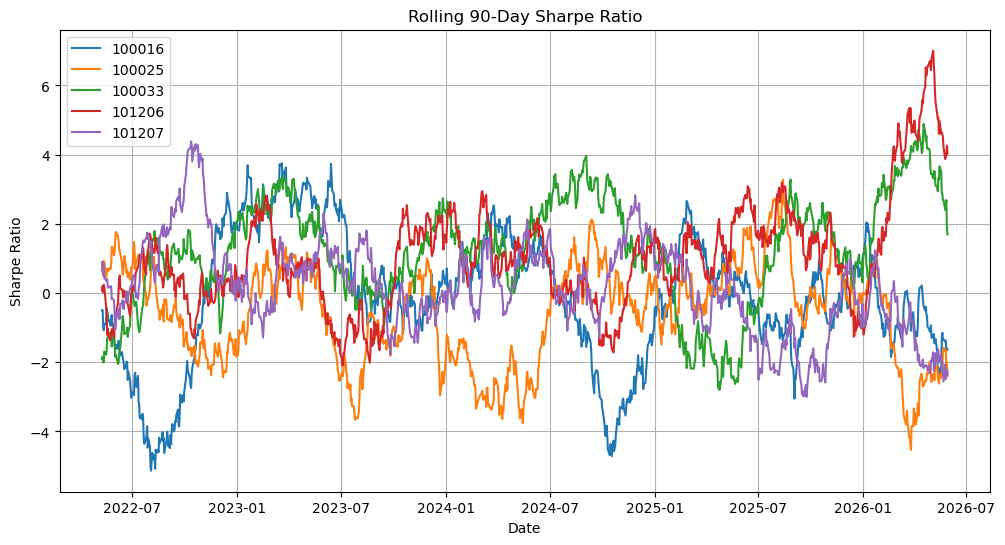

In [ ]:
import matplotlib.pyplot as plt

# Select first 5 funds
top5 = nav["amfi_code"].unique()[:5]

plt.figure(figsize=(12,6))

for fund in top5:
    temp = nav[nav["amfi_code"] == fund]
    plt.plot(temp["date"], temp["rolling_sharpe"], label=str(fund))

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)

plt.show()

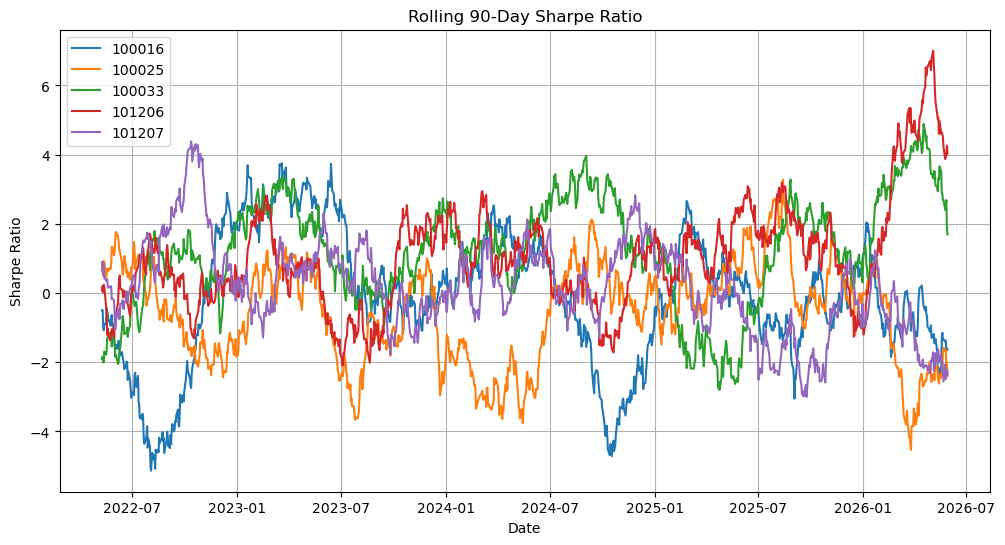

In [ ]:
plt.figure(figsize=(12,6))

for fund in top5:
    temp = nav[nav["amfi_code"] == fund]
    plt.plot(temp["date"], temp["rolling_sharpe"], label=str(fund))

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)

plt.savefig("../reports/rolling_sharpe_chart.png", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
print(investor.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


In [ ]:
# Convert transaction date to datetime
investor["transaction_date"] = pd.to_datetime(investor["transaction_date"])

# Extract transaction year
investor["transaction_year"] = investor["transaction_date"].dt.year

investor.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,transaction_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [ ]:
investor = investor.merge(first_year, on="investor_id")

investor.head()

NameError: name 'first_year' is not defined

In [ ]:
# First transaction year for every investor
first_year = (
    investor.groupby("investor_id")["transaction_year"]
    .min()
    .reset_index()
)

first_year.rename(columns={"transaction_year": "cohort_year"}, inplace=True)

first_year.head()

,investor_id,cohort_year
0,INV000001,2024
1,INV000002,2024
2,INV000003,2024
3,INV000004,2024
4,INV000005,2024


In [ ]:
investor = investor.merge(first_year, on="investor_id")

investor.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,transaction_year,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024,2024


In [ ]:
cohort = (
    investor.groupby("cohort_year")
    .agg(
        avg_sip_amount=("amount_inr", "mean"),
        total_invested=("amount_inr", "sum"),
        investors=("investor_id", "nunique")
    )
    .reset_index()
)

cohort

,cohort_year,avg_sip_amount,total_invested,investors
0,2024,107422.541832,3491125187,4803
1,2025,109158.577061,30455243,197


In [ ]:
top_fund = (
    investor.groupby(["cohort_year", "amfi_code"])
    .size()
    .reset_index(name="count")
)

top_fund = top_fund.loc[
    top_fund.groupby("cohort_year")["count"].idxmax()
]

top_fund

,cohort_year,amfi_code,count
35,2024,148568,874
62,2025,119599,12


In [ ]:
sip = investor[investor["transaction_type"] == "SIP"].copy()

sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,transaction_year,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024,2024
5,INV001497,2024-01-01,101208,SIP,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified,2024,2024
6,INV000786,2024-01-01,101208,SIP,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified,2024,2024


In [ ]:
sip = sip.sort_values(["investor_id", "transaction_date"])

sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,transaction_year,cohort_year
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,2024
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2025,2024
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,2024
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,2024
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2025,2024


In [ ]:
sip["gap_days"] = (
    sip.groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

sip.head(10)

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,transaction_year,cohort_year,gap_days
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,2024,NaN
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2025,2024,76.0
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,2024,NaN
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,2024,176.0
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2025,2024,238.0
12652,INV000003,2024-07-16,101207,SIP,2676,Gujarat,Ahmedabad,T30,26-35,Female,10.6,Mandate,Verified,2024,2024,NaN
27622,INV000003,2025-03-11,149322,SIP,15185,Gujarat,Ahmedabad,T30,26-35,Female,10.6,Mandate,Verified,2025,2024,238.0
4773,INV000004,2024-03-16,101208,SIP,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,2024,NaN
6418,INV000004,2024-04-11,119095,SIP,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,2024,2024,26.0
8271,INV000004,2024-05-09,120844,SIP,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,2024,28.0


In [ ]:
sip_summary = (
    sip.groupby("investor_id")
    .agg(
        sip_count=("transaction_date", "count"),
        avg_gap=("gap_days", "mean")
    )
    .reset_index()
)

sip_summary = sip_summary[sip_summary["sip_count"] >= 6]

sip_summary.head()

,investor_id,sip_count,avg_gap
3,INV000004,6,85.400000
7,INV000008,6,70.400000
9,INV000010,6,64.800000
10,INV000011,7,40.166667
11,INV000012,8,57.000000


In [ ]:
sip_summary["status"] = sip_summary["avg_gap"].apply(
    lambda x: "At-Risk" if x > 35 else "Regular"
)

sip_summary.head()

,investor_id,sip_count,avg_gap,status
3,INV000004,6,85.400000,At-Risk
7,INV000008,6,70.400000,At-Risk
9,INV000010,6,64.800000,At-Risk
10,INV000011,7,40.166667,At-Risk
11,INV000012,8,57.000000,At-Risk


In [ ]:
sip_summary["status"] = sip_summary["avg_gap"].apply(
    lambda x: "At-Risk" if x > 35 else "Regular"
)

sip_summary.head()

,investor_id,sip_count,avg_gap,status
3,INV000004,6,85.400000,At-Risk
7,INV000008,6,70.400000,At-Risk
9,INV000010,6,64.800000,At-Risk
10,INV000011,7,40.166667,At-Risk
11,INV000012,8,57.000000,At-Risk


NameError: name 'pd' is not defined

In [ ]:
import pandas as pd

In [ ]:
performance = pd.read_csv("../data/processed/07_scheme_performance_cleaned.csv")

print(performance.columns.tolist())

['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


In [ ]:
print(portfolio.columns.tolist())

NameError: name 'portfolio' is not defined

In [9]:
import pandas as pd

portfolio = pd.read_csv("../data/processed/09_portfolio_holdings_cleaned.csv")

In [10]:
print(portfolio.columns.tolist())

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [11]:
# Calculate HHI for each fund

hhi = (
    portfolio.groupby("amfi_code")["weight_pct"]
    .apply(lambda x: ((x / 100) ** 2).sum())
    .reset_index(name="HHI")
)

hhi.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [13]:
hhi = hhi.merge(
    fund_master[["amfi_code", "scheme_name", "category"]],
    on="amfi_code",
    how="left"
)

hhi.head()

NameError: name 'fund_master' is not defined

In [14]:
import pandas as pd

fund_master = pd.read_csv("../data/processed/01_fund_master_cleaned.csv")

In [15]:
import pandas as pd

fund_master = pd.read_csv("../data/processed/01_fund_master_cleaned.csv")

In [16]:
hhi = hhi.merge(
    fund_master[["amfi_code", "scheme_name", "category"]],
    on="amfi_code",
    how="left"
)

hhi.head()

,amfi_code,HHI,scheme_name,category
0,100016,0.139534,HDFC Top 100 Fund - Regular Plan - Growth,Equity
1,100033,0.147592,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity
2,101206,0.129332,ABSL Frontline Equity Fund - Regular - Growth,Equity
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth,Equity
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth,Equity


In [17]:
equity_hhi = hhi[
    hhi["category"].str.contains("Equity", case=False, na=False)
]

equity_hhi.sort_values(
    by="HHI",
    ascending=False
).head(10)

,amfi_code,HHI,scheme_name,category
11,119092,0.206448,Axis Bluechip Fund - Regular - Growth,Equity
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth,Equity
18,119599,0.174751,SBI Small Cap Fund - Direct Plan - Growth,Equity
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth,Equity
7,118632,0.168298,Nippon India Large Cap Fund - Regular - Growth,Equity
29,148568,0.167930,Mirae Asset Emerging Bluechip Fund - Regular -...,Equity
21,120505,0.157570,ICICI Pru Midcap Fund - Regular - Growth,Equity
22,120506,0.153794,ICICI Pru Value Discovery Fund - Regular - Growth,Equity
27,125498,0.152414,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Equity
23,120841,0.149680,Kotak Bluechip Fund - Regular - Growth,Equity


### Insight 1
Historical VaR and CVaR analysis identified funds with the highest downside risk, helping investors understand potential losses during adverse market conditions.

### Insight 2
Rolling 90-day Sharpe Ratio showed that fund performance varied over time, with some funds consistently delivering better risk-adjusted returns.

### Insight 3
Investor cohort analysis revealed differences in average investment amounts and preferred mutual funds across different entry years.

### Insight 4
SIP continuity analysis identified investors with an average SIP gap greater than 35 days as 'At-Risk', enabling early intervention for improving investment continuity.

### Insight 5
Sector concentration analysis using the Herfindahl-Hirschman Index (HHI) highlighted which equity funds had highly concentrated portfolios versus more diversified holdings.